# 1. Import evaluation function

In [9]:
import sys

sys.path.append("..")

from src.utils.evaluation import evaluate_model

# 2. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

from xgboost import XGBClassifier

# 3. Load processed datasets

In [2]:
X_train_smote = joblib.load("../models/X_train_smote.pkl")
y_train_smote = joblib.load("../models/y_train_smote.pkl")

X_test_processed = joblib.load("../models/X_test_processed.pkl")
y_test = joblib.load("../models/y_test.pkl")

# 4. Create XGBoost

In [3]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# 5. Parameter Grid

In [4]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[3,4,5,6],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.7,0.8,1],

    "colsample_bytree":[0.7,0.8,1],

    "gamma":[0,0.1,0.2],

    "min_child_weight":[1,3,5]
}

# 6. RandomizedSearchCV

In [5]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,

    n_iter=10,

    scoring="average_precision",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=1
)

# 7. Fit

In [6]:
random_search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=200, subsample=1; total time=  35.1s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=200, subsample=1; total time=  36.6s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=200, subsample=1; total time=  36.4s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=5, n_estimators=300, subsample=0.8; total time=  34.3s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=5, n_estimators=300, subsample=0.8; total time=  36.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=5, n_estimators=300, subsample=0.8; total time=  36.7s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4,

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function 

# 8. Best Parameters

In [7]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}

Best CV Score:
0.999995107361005


# 9. Save tuned model

In [8]:
best_xgb = random_search.best_estimator_

import joblib

joblib.dump(best_xgb, "../models/xgboost_tuned.pkl")

print("Tuned XGBoost saved!")

Tuned XGBoost saved!


# 10. Evaluate tuned model

Tuned XGBoost
Accuracy : 0.9983
Precision: 1.0000
Recall   : 0.8125
F1 Score : 0.8966
ROC AUC  : 0.9998
PR AUC   : 0.9830

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      0.81      0.90        16

    accuracy                           1.00      1817
   macro avg       1.00      0.91      0.95      1817
weighted avg       1.00      1.00      1.00      1817



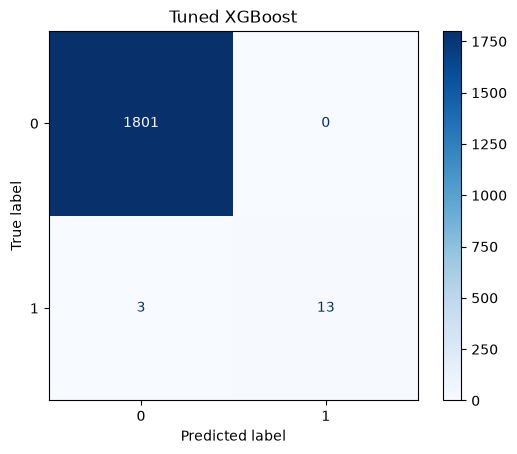

{'Accuracy': 0.9983489268024216,
 'Precision': 1.0,
 'Recall': 0.8125,
 'F1': 0.896551724137931,
 'ROC_AUC': 0.9997917823431427,
 'PR_AUC': 0.9829545454545454}

In [10]:
evaluate_model(
    best_xgb,
    X_test_processed,
    y_test,
    "Tuned XGBoost"
)